<a href="https://colab.research.google.com/github/Venu-max/NASSCOM-AI/blob/main/Day2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
## Linear Algebra
# Core imports for the whole lab
import numpy as np
import numpy.linalg as la          # inv, norm, eig, solve, matrix_rank
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)   # tidy array printing
np.random.seed(42)
print('Setup complete. NumPy', np.__version__)

Setup complete. NumPy 2.0.2


In [2]:
#1. Scalars, vectors, matrices & tensors
# 1A. THE FOUR CONTAINERS
scalar = np.array(5)                  # 0-D: a single number
vector = np.array([2, 5, 1])          # 1-D: a list of numbers
matrix = np.array([[1, 2], [3, 4]])   # 2-D: rows x columns
tensor = np.ones((3, 2, 2))           # n-D: a stack of matrices

# .ndim = number of dimensions, .shape = size along each dimension
for name, arr in [('scalar', scalar), ('vector', vector),
                  ('matrix', matrix), ('tensor', tensor)]:
    print(f'{name:7s} ndim={arr.ndim}  shape={arr.shape}')


scalar  ndim=0  shape=()
vector  ndim=1  shape=(3,)
matrix  ndim=2  shape=(2, 2)
tensor  ndim=3  shape=(3, 2, 2)


In [3]:
# 🔹 1B. TENSOR OPERATIONS: add, transpose, reshape
# -----------------------------------------------------------

A = np.arange(6).reshape(2, 3)   # shape (2, 3)
B = np.ones((2, 3), dtype=int)

print('A:\n', A)
print('A + B (element-wise add):\n', A + B)
print('A.T  (transpose -> shape', A.T.shape, '):\n', A.T)
print('A.reshape(3, 2):\n', A.reshape(3, 2))
print('A.flatten():', A.flatten())

A:
 [[0 1 2]
 [3 4 5]]
A + B (element-wise add):
 [[1 2 3]
 [4 5 6]]
A.T  (transpose -> shape (3, 2) ):
 [[0 3]
 [1 4]
 [2 5]]
A.reshape(3, 2):
 [[0 1]
 [2 3]
 [4 5]]
A.flatten(): [0 1 2 3 4 5]


In [5]:
#LAB EXERCISE 1 — Tensor ops: add, transpose, reshape
#Using the array T provided below:

#Print its ndim and shape.
#Add T to itself and print the result.
#Transpose T and print the new shape, then reshape T into shape (2, 6).
import numpy as np

T = np.arange(12).reshape(3, 4)

# 1. ndim and shape
print("ndim:", T.ndim)
print("shape:", T.shape)

# 2. Add T to itself
print("\nT + T:")
print(T + T)

# 3. Transpose
print("\nTranspose:")
print(T.T)
print("Transpose shape:", T.T.shape)

# 4. Reshape
print("\nReshape to (2,6):")
print(T.reshape(2, 6))
print("Reshaped shape:", T.reshape(2, 6).shape)

ndim: 2
shape: (3, 4)

T + T:
[[ 0  2  4  6]
 [ 8 10 12 14]
 [16 18 20 22]]

Transpose:
[[ 0  4  8]
 [ 1  5  9]
 [ 2  6 10]
 [ 3  7 11]]
Transpose shape: (4, 3)

Reshape to (2,6):
[[ 0  1  2  3  4  5]
 [ 6  7  8  9 10 11]]
Reshaped shape: (2, 6)


In [7]:
##2. Dot & cross products, and norms
#🔹 2A. DOT & CROSS PRODUCTS
# -----------------------------------------------------------

a = np.array([1, 2, 3])
b = np.array([4, 0, 1])

# Dot product: sum of element-wise products -> measures alignment
print('a . b  (dot)   :', np.dot(a, b))      # 1*4 + 2*0 + 3*1 = 7

# Cross product: a new vector perpendicular to both (3-D only)
print('a x b  (cross) :', np.cross(a, b))

a . b  (dot)   : 7
a x b  (cross) : [ 2 11 -8]


In [8]:
# -----------------------------------------------------------
# 🔹 2B. NORMS (vector length) + COSINE SIMILARITY
# -----------------------------------------------------------

print('L2 norm  ||a||_2 :', la.norm(a))         # sqrt(sum of squares)
print('L1 norm  ||a||_1 :', la.norm(a, 1))      # sum of absolute values
print('Linf norm        :', la.norm(a, np.inf)) # max absolute value

# Cosine similarity: the angle between vectors, ignoring magnitude
def cosine(u, v):
    return np.dot(u, v) / (la.norm(u) * la.norm(v))

print('cosine(a, b)     :', round(cosine(a, b), 3))

L2 norm  ||a||_2 : 3.7416573867739413
L1 norm  ||a||_1 : 6.0
Linf norm        : 3.0
cosine(a, b)     : 0.454


In [9]:
#LAB EXERCISE 2 — L1/L2 norms + cosine similarity on 3 vector pairs
#Three vector pairs are provided in pairs. For each pair (u, v):

#Print the L1 and L2 norm of u.
#Print the cosine similarity between u and v (reuse the cosine function above).
#Which pair is the most similar? Note it in a comment.
import numpy as np
import numpy.linalg as la

def cosine(u, v):
    return np.dot(u, v) / (la.norm(u) * la.norm(v))

pair1_u = np.array([1, 2, 3])
pair1_v = np.array([2, 4, 6])

pair2_u = np.array([1, 0, 0])
pair2_v = np.array([0, 1, 0])

pair3_u = np.array([1, 2, 3])
pair3_v = np.array([3, 2, 1])

pairs = [
    (pair1_u, pair1_v),
    (pair2_u, pair2_v),
    (pair3_u, pair3_v)
]

for i, (u, v) in enumerate(pairs, start=1):
    print(f"\nPair {i}")
    print("u =", u)
    print("v =", v)
    print("L1 norm of u =", la.norm(u, 1))
    print("L2 norm of u =", la.norm(u))
    print("Cosine similarity =", round(cosine(u, v), 3))

# Pair 1 is the most similar because its cosine similarity is 1.0


Pair 1
u = [1 2 3]
v = [2 4 6]
L1 norm of u = 6.0
L2 norm of u = 3.7416573867739413
Cosine similarity = 1.0

Pair 2
u = [1 0 0]
v = [0 1 0]
L1 norm of u = 1.0
L2 norm of u = 1.0
Cosine similarity = 0.0

Pair 3
u = [1 2 3]
v = [3 2 1]
L1 norm of u = 6.0
L2 norm of u = 3.7416573867739413
Cosine similarity = 0.714


In [10]:
##3. Matrix operations & special matrices
# -----------------------------------------------------------
# 🔹 3A. CORE MATRIX OPERATIONS
# -----------------------------------------------------------

A = np.array([[2., 1.],
              [1., 3.]])
B = np.array([[1., 0.],
              [4., 2.]])

print('A @ B (matrix multiply):\n', A @ B)
print('A.T   (transpose):\n', A.T)
print('inverse(A):\n', la.inv(A))
print('trace(A) = sum of diagonal:', np.trace(A))

A @ B (matrix multiply):
 [[ 6.  2.]
 [13.  6.]]
A.T   (transpose):
 [[2. 1.]
 [1. 3.]]
inverse(A):
 [[ 0.6 -0.2]
 [-0.2  0.4]]
trace(A) = sum of diagonal: 5.0


In [11]:

# -----------------------------------------------------------
# 🔹 3B. SPECIAL MATRICES: identity, symmetric, orthogonal
# -----------------------------------------------------------

I = np.eye(2)                       # identity: 1s on the diagonal
print('Identity I:\n', I)
print('A @ inv(A) == I ?', np.allclose(A @ la.inv(A), I))

# Symmetric: A equals its own transpose
print('A symmetric?', np.allclose(A, A.T))

# Orthogonal: Q.T @ Q == I (a pure rotation/reflection)
theta = np.radians(30)
Q = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])
print('Q orthogonal?', np.allclose(Q.T @ Q, I))

Identity I:
 [[1. 0.]
 [0. 1.]]
A @ inv(A) == I ? True
A symmetric? True
Q orthogonal? True


In [12]:
#LAB EXERCISE 3 — Inverse, trace, and matrix tests
#Using matrix M below:

#Print inverse(M) and trace(M).
#Verify that M @ inverse(M) is the identity (use np.allclose).
#Test whether M is symmetric and whether P (provided) is orthogonal.
import numpy as np
import numpy.linalg as la

M = np.array([[4., 2.],
              [2., 3.]])

P = np.array([[0., -1.],
              [1.,  0.]])

# 1. Inverse and trace
print("Inverse of M:")
print(la.inv(M))

print("\nTrace of M:")
print(np.trace(M))

# 2. Verify M @ inv(M) = I
I = np.eye(2)

print("\nM @ inv(M) == I ?")
print(np.allclose(M @ la.inv(M), I))

# 3. Matrix tests
print("\nIs M symmetric?")
print(np.allclose(M, M.T))

print("\nIs P orthogonal?")
print(np.allclose(P.T @ P, I))

Inverse of M:
[[ 0.375 -0.25 ]
 [-0.25   0.5  ]]

Trace of M:
7.0

M @ inv(M) == I ?
True

Is M symmetric?
True

Is P orthogonal?
True


In [13]:
##4. Transformations: rotation & scaling
# -----------------------------------------------------------
# 🔹 4A. BUILD TRANSFORMATION MATRICES
# -----------------------------------------------------------

# A unit square defined by its 4 corners (each column is a point)
square = np.array([[0, 1, 1, 0],
                   [0, 0, 1, 1]], dtype=float)

# Scaling matrix: stretch x by 1.5, y by 0.5
S = np.array([[1.5, 0.0],
              [0.0, 0.5]])

# Rotation matrix: rotate by 30 degrees
t = np.radians(30)
R = np.array([[np.cos(t), -np.sin(t)],
              [np.sin(t),  np.cos(t)]])

scaled  = S @ square      # apply scaling
rotated = R @ square      # apply rotation
print('Rotated corners:\n', rotated)

Rotated corners:
 [[ 0.     0.866  0.366 -0.5  ]
 [ 0.     0.5    1.366  0.866]]


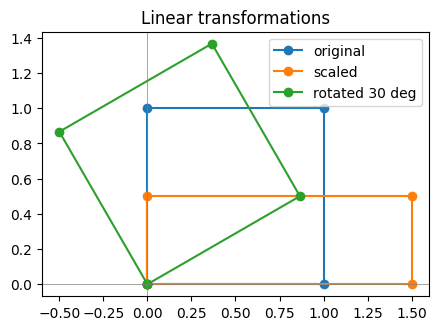

In [14]:
# -----------------------------------------------------------
# 🔹 4B. PLOT ORIGINAL vs TRANSFORMED
# -----------------------------------------------------------

def close_loop(pts):
    # repeat the first point at the end so the polygon closes
    return np.hstack([pts, pts[:, :1]])

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(*close_loop(square),  marker='o', label='original')
ax.plot(*close_loop(scaled),  marker='o', label='scaled')
ax.plot(*close_loop(rotated), marker='o', label='rotated 30 deg')
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.set_aspect('equal'); ax.legend(); ax.set_title('Linear transformations')
plt.show()

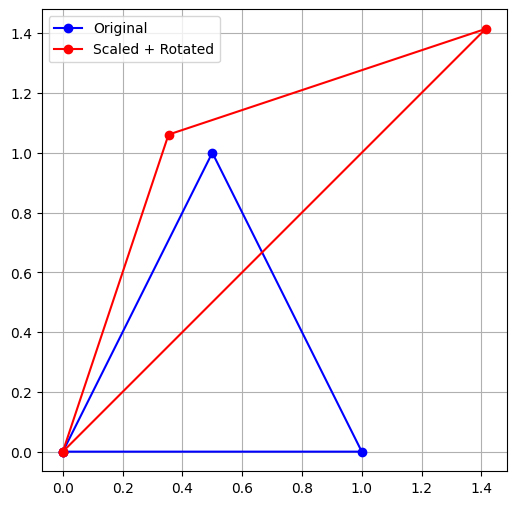

In [15]:
#LAB EXERCISE 4 — Apply 2 transformations & plot
#Start from the tri triangle below:

#Build a scaling matrix that doubles x and halves y.
#Build a rotation matrix for 45 degrees.
#Apply both (one after another) and plot the original vs the transformed triangle.
#Hint: reuse close_loop and the plotting pattern from 4B.
import numpy as np
import matplotlib.pyplot as plt

# Original triangle
tri = np.array([[0, 1, 0.5],
                [0, 0, 1.0]])

# Scaling matrix
S = np.array([[2, 0],
              [0, 0.5]])

# Rotation matrix (45 degrees)
theta = np.radians(45)

R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])

# Apply scaling
scaled = S @ tri

# Apply rotation
transformed = R @ scaled

# Function to close the triangle
def close_loop(P):
    return np.hstack([P, P[:, :1]])

# Close shapes
tri_closed = close_loop(tri)
trans_closed = close_loop(transformed)

# Plot
plt.figure(figsize=(6,6))

plt.plot(tri_closed[0], tri_closed[1],
         'bo-', label="Original")

plt.plot(trans_closed[0], trans_closed[1],
         'ro-', label="Scaled + Rotated")

plt.axis("equal")
plt.grid(True)
plt.legend()

plt.show()

In [16]:
##5. Eigenvalues & eigenvectors
# -----------------------------------------------------------
# 🔹 5A. COMPUTE EIGENVALUES & EIGENVECTORS
# -----------------------------------------------------------

A = np.array([[2., 0.],
              [0., 3.]])

vals, vecs = la.eig(A)     # vals = eigenvalues, vecs columns = eigenvectors
print('Eigenvalues  (lambda):', vals)
print('Eigenvectors (columns):\n', vecs)


Eigenvalues  (lambda): [2. 3.]
Eigenvectors (columns):
 [[1. 0.]
 [0. 1.]]


In [17]:
# -----------------------------------------------------------
# 🔹 5B. VERIFY  A v = lambda v
# -----------------------------------------------------------

for i in range(len(vals)):
    v = vecs[:, i]                 # i-th eigenvector
    lhs = A @ v                    # A v
    rhs = vals[i] * v              # lambda v
    print(f'lambda={vals[i]:.1f}  A v == lambda v ?', np.allclose(lhs, rhs))


lambda=2.0  A v == lambda v ? True
lambda=3.0  A v == lambda v ? True


In [18]:
##LAB EXERCISE 5 — Eigenvalues/vectors & verification
#Using matrix C below:

#Compute its eigenvalues and eigenvectors with la.eig.
#Print the eigenvalues.
#Verify C @ v == lambda * v for the first eigenvector using np.allclose.
import numpy as np
import numpy.linalg as la

C = np.array([[4., 1.],
              [2., 3.]])

# Compute eigenvalues and eigenvectors
eigenvalues, eigenvectors = la.eig(C)

# Print eigenvalues
print("Eigenvalues:")
print(eigenvalues)

# Print eigenvectors
print("\nEigenvectors:")
print(eigenvectors)

# First eigenvalue and eigenvector
lam = eigenvalues[0]
v = eigenvectors[:, 0]

# Verify C @ v = lambda * v
print("\nC @ v:")
print(C @ v)

print("\nlambda * v:")
print(lam * v)

print("\nVerification:")
print(np.allclose(C @ v, lam * v))

Eigenvalues:
[5. 2.]

Eigenvectors:
[[ 0.707 -0.447]
 [ 0.707  0.894]]

C @ v:
[3.536 3.536]

lambda * v:
[3.536 3.536]

Verification:
True


In [19]:
##6. Rank, solving systems & cosine similarity
# -----------------------------------------------------------
# 🔹 6A. SOLVE A 3x3 SYSTEM  A x = b
# -----------------------------------------------------------

A = np.array([[ 2.,  1., -1.],
              [-3., -1.,  2.],
              [-2.,  1.,  2.]])
b = np.array([8., -11., -3.])

x = la.solve(A, b)
print('Solution x:', x)                    # [2, 3, -1]
print('Rank of A :', la.matrix_rank(A))     # 3 -> full rank
print('Full rank -> a unique solution exists')

Solution x: [ 2.  3. -1.]
Rank of A : 3
Full rank -> a unique solution exists


In [20]:
# -----------------------------------------------------------
# 🔹 6B. RANK TELLS YOU SOLVABILITY
# -----------------------------------------------------------

# A rank-deficient matrix: row 3 = row 1 + row 2 (not independent)
D = np.array([[1., 2., 3.],
              [4., 5., 6.],
              [5., 7., 9.]])
print('Rank of D:', la.matrix_rank(D), '-> < 3, so rows are dependent')

Rank of D: 2 -> < 3, so rows are dependent


In [21]:
# -----------------------------------------------------------
# 🔹 6C. COSINE SIMILARITY ON 'EMBEDDINGS'
# -----------------------------------------------------------

# Toy 4-D embeddings (in practice these come from a model)
king  = np.array([0.8, 0.6, 0.1, 0.2])
queen = np.array([0.7, 0.7, 0.1, 0.3])
apple = np.array([0.1, 0.0, 0.9, 0.8])

print('cosine(king, queen):', round(cosine(king, queen), 3))   # high
print('cosine(king, apple):', round(cosine(king, apple), 3))   # low


cosine(king, queen): 0.986
cosine(king, apple): 0.267


In [ ]:
##Python for AI/ML (Part 2): Lab
##The Data & ML Library Stack — NumPy · Pandas · Matplotlib & Seaborn · scikit-learn · Data flow

In [7]:
# Core imports for the whole lab
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix

sns.set_theme(style='whitegrid')   # nicer default plot styling
np.random.seed(42)                 # reproducible results
print('Setup complete. NumPy', np.__version__, '| Pandas', pd.__version__)

Setup complete. NumPy 2.0.2 | Pandas 2.2.2


In [ ]:
##1. NumPy — arrays & linear algebra

In [8]:
# -----------------------------------------------------------
# 🔹 1A. ARRAY CREATION & SHAPE
# -----------------------------------------------------------

# arange() builds a range; reshape() changes the shape without copying data
a = np.arange(6).reshape(2, 3)
print('Array a:\n', a)

# Inspect the array's structure
print('shape :', a.shape)     # (2, 3)  -> 2 rows, 3 cols
print('ndim  :', a.ndim)      # 2       -> number of dimensions
print('dtype :', a.dtype)     # int64   -> data type of elements

Array a:
 [[0 1 2]
 [3 4 5]]
shape : (2, 3)
ndim  : 2
dtype : int64


In [9]:
# -----------------------------------------------------------
# 🔹 1B. SLICING & INDEXING
# -----------------------------------------------------------

print('Column index 1 :', a[:, 1])        # all rows, 2nd column
print('Row index 0    :', a[0, :])        # 1st row, all columns

# Boolean mask: keep only the elements that satisfy a condition
print('Elements > 2   :', a[a > 2])


Column index 1 : [1 4]
Row index 0    : [0 1 2]
Elements > 2   : [3 4 5]


In [10]:
# -----------------------------------------------------------
# 🔹 1C. BROADCASTING
# -----------------------------------------------------------

# Broadcasting lets NumPy combine arrays of different shapes without loops
row = np.array([10, 20, 30])   # shape (3,)
print('a + row (row added to every row of a):\n', a + row)

a + row (row added to every row of a):
 [[10 21 32]
 [13 24 35]]


In [13]:

# -----------------------------------------------------------
# 🔹 1D. MATRIX MULTIPLICATION + AXIS-WISE OPERATIONS  (core demo)
# -----------------------------------------------------------

b = np.ones((3, 2), dtype=int)   # shape (3, 2)
print('Matrix product a @ b:\n', a @ b)   # (2,3) @ (3,2) -> (2,2)

# Axis-wise reductions: axis=0 collapses rows, axis=1 collapses columns
print('Column-wise sum  (axis=0):', a.sum(axis=0))
print('Row-wise sum     (axis=1):', a.sum(axis=1))
print('Row-wise mean    (axis=1):', a.mean(axis=1))
print('Index of max per column  :', a.argmax(axis=0))

Matrix product a @ b:
 [[ 3  3]
 [12 12]]
Column-wise sum  (axis=0): [3 5 7]
Row-wise sum     (axis=1): [ 3 12]
Row-wise mean    (axis=1): [1. 4.]
Index of max per column  : [1 1 1]


In [ ]:
##LAB EXERCISE 1 — Matrix multiplication + axis-wise operations
"""Using the 2-D array M provided below:

Multiply M by N with the @ operator and print the result.
Print the column-wise sum and the row-wise mean of M.
Print the index of the maximum value in each row of M."""

In [12]:
import numpy as np

# Given data
M = np.arange(1, 13).reshape(3, 4)
N = np.arange(1, 9).reshape(4, 2)

print("M:\n", M)
print("N:\n", N)

# 1. Matrix multiplication
print("\nM @ N:")
print(M @ N)

# 2. Column-wise sum
print("\nColumn-wise sum:")
print(M.sum(axis=0))

# 3. Row-wise mean
print("\nRow-wise mean:")
print(M.mean(axis=1))

# 4. Index of maximum value in each row
print("\nIndex of maximum value in each row:")
print(M.argmax(axis=1))

M:
 [[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]
N:
 [[1 2]
 [3 4]
 [5 6]
 [7 8]]

M @ N:
[[ 50  60]
 [114 140]
 [178 220]]

Column-wise sum:
[15 18 21 24]

Row-wise mean:
[ 2.5  6.5 10.5]

Index of maximum value in each row:
[3 3 3]


In [ ]:
##2. Pandas — load, clean & group

In [14]:
# -----------------------------------------------------------
# 🔹 2A. LOAD & INSPECT
# -----------------------------------------------------------

# Load the classic Titanic dataset (built into seaborn).
# In your own work this would be: pd.read_csv('titanic.csv')
df = sns.load_dataset('titanic')

print('Shape:', df.shape)
df.head()

Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [16]:
# .info() shows columns, dtypes and non-null counts -> spot missing data fast
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [17]:
# .describe() gives summary statistics for the numeric columns
df.describe()


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [18]:
# -----------------------------------------------------------
# 🔹 2B. HANDLE MISSING VALUES
# -----------------------------------------------------------

# Count missing values per column
print('Missing values per column:')
print(df.isna().sum().sort_values(ascending=False).head())

# Fill missing 'age' with the median (a common, robust strategy)
df['age'] = df['age'].fillna(df['age'].median())
print('\nMissing ages after fillna:', df['age'].isna().sum())

Missing values per column:
deck           688
age            177
embarked         2
embark_town      2
sex              0
dtype: int64

Missing ages after fillna: 0


In [19]:
# -----------------------------------------------------------
# 🔹 2C. GROUP BY A CATEGORY  (split -> apply -> combine)
# -----------------------------------------------------------

# Average survival rate by passenger class
print('Survival rate by class:')
print(df.groupby('class', observed=True)['survived'].mean())

# Two-level grouping: survival by class AND sex
print('\nSurvival rate by class and sex:')
print(df.groupby(['class', 'sex'], observed=True)['survived'].mean())

Survival rate by class:
class
First     0.629630
Second    0.472826
Third     0.242363
Name: survived, dtype: float64

Survival rate by class and sex:
class   sex   
First   female    0.968085
        male      0.368852
Second  female    0.921053
        male      0.157407
Third   female    0.500000
        male      0.135447
Name: survived, dtype: float64


In [20]:

# LAB EXERCISE 2
# Load, fill missing values, and group by category

import seaborn as sns
import pandas as pd

# Load a fresh copy of the Titanic dataset
lab = sns.load_dataset("titanic")

# -------------------------------------------------
# 1. Print how many values are missing in embarked
# -------------------------------------------------

print("Missing values in 'embarked' column:")
print(lab["embarked"].isna().sum())

# -------------------------------------------------
# 2. Fill missing embarked values with the mode
# -------------------------------------------------

mode_value = lab["embarked"].mode()[0]

lab["embarked"] = lab["embarked"].fillna(mode_value)

print("\nMissing values after fillna:")
print(lab["embarked"].isna().sum())

# -------------------------------------------------
# 3. Group by sex and print the mean fare
# -------------------------------------------------

print("\nMean fare paid by each sex:")

mean_fare = lab.groupby("sex")["fare"].mean()

print(mean_fare)


Missing values in 'embarked' column:
2

Missing values after fillna:
0

Mean fare paid by each sex:
sex
female    44.479818
male      25.523893
Name: fare, dtype: float64


In [ ]:
##3. Matplotlib & Seaborn — visualize

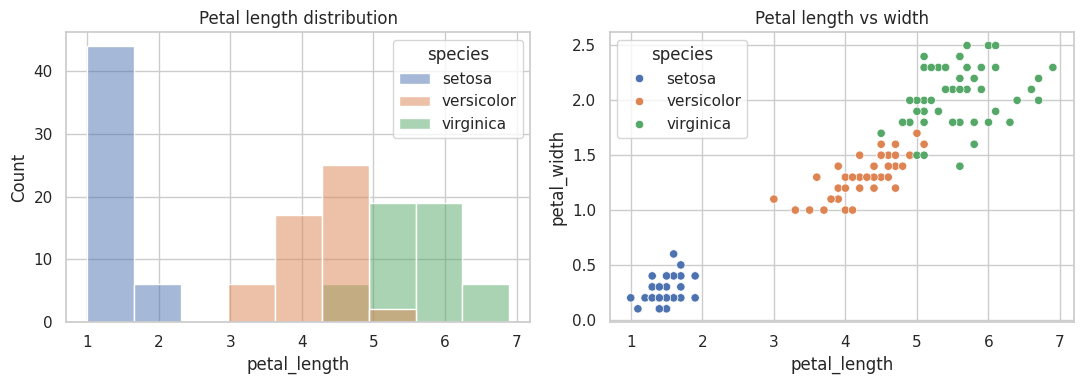

In [21]:
# -----------------------------------------------------------
# 🔹 3A. SUBPLOT COMPARISON  (Matplotlib)
# -----------------------------------------------------------

iris = sns.load_dataset('iris')   # 150 flowers, 4 measurements, 3 species

# plt.subplots() makes a grid of axes for side-by-side charts
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.histplot(data=iris, x='petal_length', hue='species', ax=axes[0])
axes[0].set_title('Petal length distribution')

sns.scatterplot(data=iris, x='petal_length', y='petal_width',
                hue='species', ax=axes[1])
axes[1].set_title('Petal length vs width')

plt.tight_layout()
plt.show()

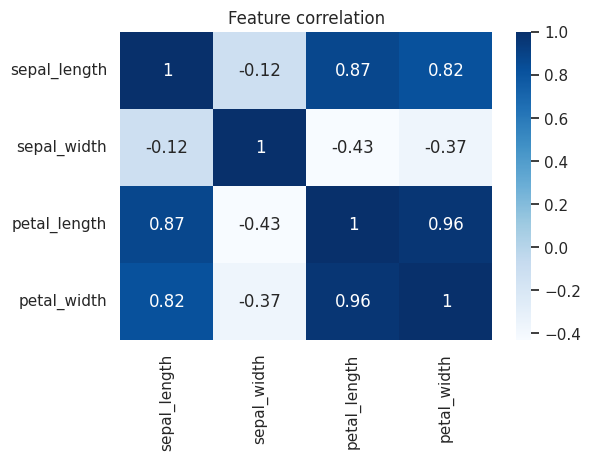

In [22]:
# -----------------------------------------------------------
# 🔹 3B. CORRELATION HEATMAP  (Seaborn)
# -----------------------------------------------------------

# .corr() on the numeric columns, visualised as a heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(iris.drop(columns='species').corr(),
            annot=True, cmap='Blues')
plt.title('Feature correlation')
plt.show()

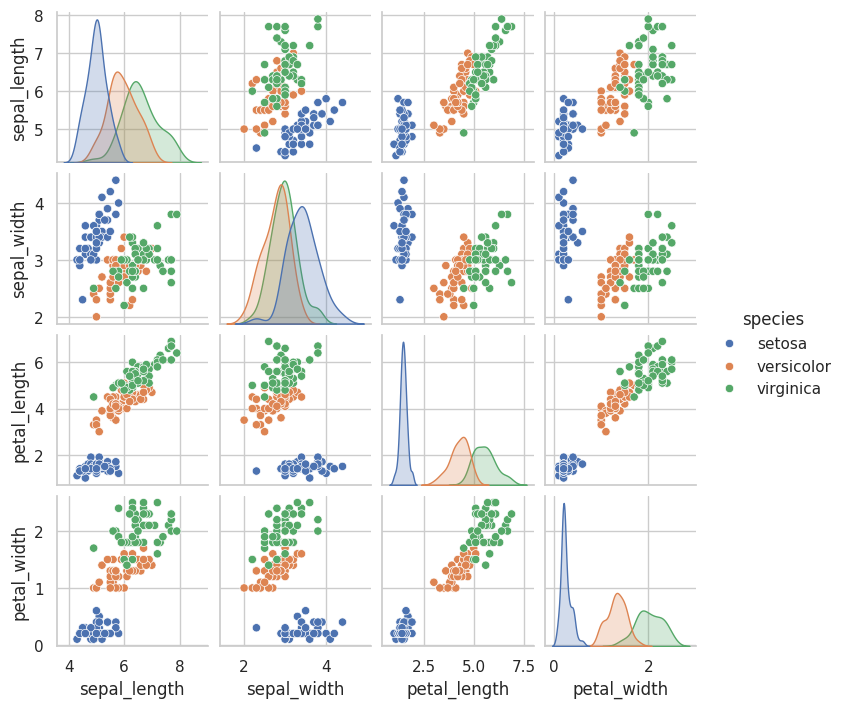

In [23]:
# -----------------------------------------------------------
# 🔹 3C. PAIRPLOT  (every feature vs every feature)
# -----------------------------------------------------------

# A pairplot draws scatter plots for all feature pairs at once,
# coloured by class -> a fast way to see how separable the classes are.
sns.pairplot(iris, hue='species', height=1.8)
plt.show()

Dataset Shape after dropna():
(333, 7)


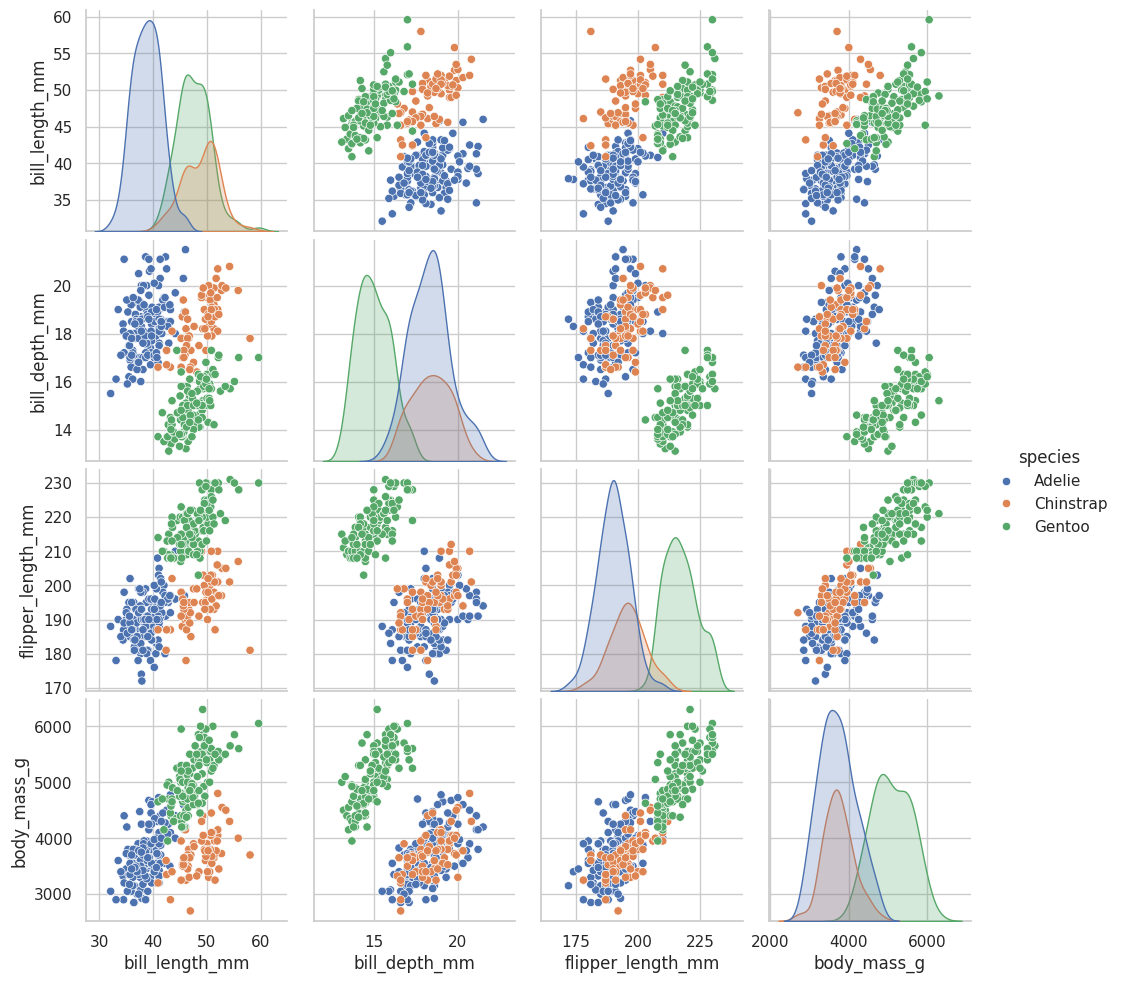

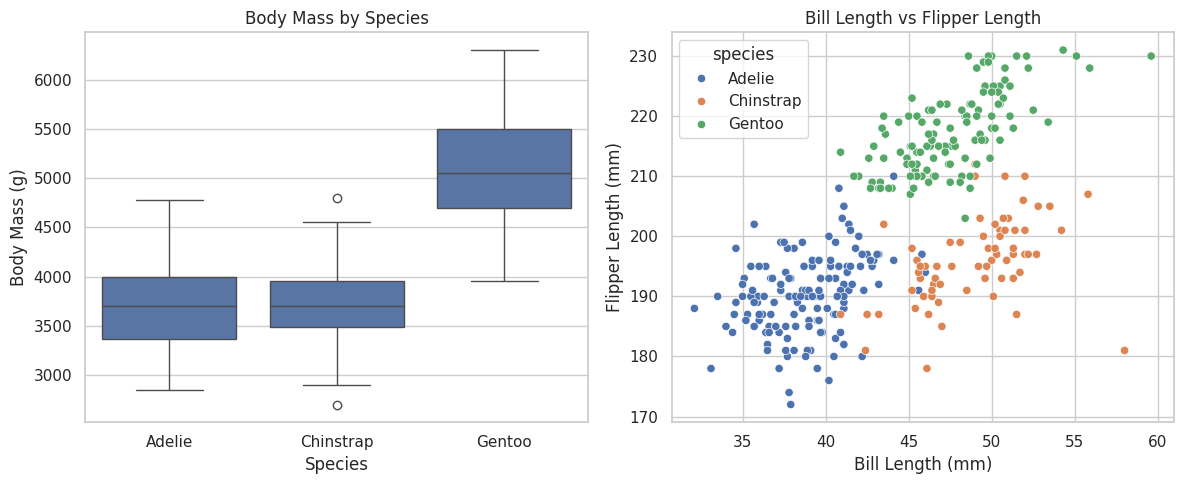

In [24]:

# LAB EXERCISE 3
# Pairplot + Subplot Comparison

import seaborn as sns
import matplotlib.pyplot as plt

# ----------------------------------------
# Load the penguins dataset
# ----------------------------------------

pen = sns.load_dataset("penguins")

# ----------------------------------------
# Drop rows with missing values
# ----------------------------------------

pen = pen.dropna()

print("Dataset Shape after dropna():")
print(pen.shape)

# ----------------------------------------
# Pairplot coloured by species
# ----------------------------------------

sns.pairplot(
    pen,
    hue="species"
)

plt.show()

# ----------------------------------------
# Create a 1 x 2 subplot
# ----------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ----------------------------------------
# Left subplot: Boxplot
# ----------------------------------------

sns.boxplot(
    data=pen,
    x="species",
    y="body_mass_g",
    ax=axes[0]
)

axes[0].set_title("Body Mass by Species")
axes[0].set_xlabel("Species")
axes[0].set_ylabel("Body Mass (g)")

# ----------------------------------------
# Right subplot: Scatter Plot
# ----------------------------------------

sns.scatterplot(
    data=pen,
    x="bill_length_mm",
    y="flipper_length_mm",
    hue="species",
    ax=axes[1]
)

axes[1].set_title("Bill Length vs Flipper Length")
axes[1].set_xlabel("Bill Length (mm)")
axes[1].set_ylabel("Flipper Length (mm)")

plt.tight_layout()

plt.show()

In [ ]:
#4. scikit-learn — your first model

In [25]:
# -----------------------------------------------------------
# 🔹 4A. LOAD DATA & SPLIT
# -----------------------------------------------------------

# Load iris as feature matrix X and target vector y
X, y = load_iris(return_X_y=True)
print('Features X:', X.shape, '| Target y:', y.shape)

# Hold out 20% of the data for testing. stratify keeps class balance.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print('Train:', X_train.shape[0], 'samples | Test:', X_test.shape[0], 'samples')

Features X: (150, 4) | Target y: (150,)
Train: 120 samples | Test: 30 samples


In [26]:
# -----------------------------------------------------------
# 🔹 4B. FIT -> PREDICT -> EVALUATE  (the estimator API)
# -----------------------------------------------------------

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)               # learn from training data
pred = clf.predict(X_test)              # score new samples

print('Accuracy:', round(accuracy_score(y_test, pred), 3))
print('Confusion matrix:\n', confusion_matrix(y_test, pred))

Accuracy: 0.9
Confusion matrix:
 [[10  0  0]
 [ 0  9  1]
 [ 0  2  8]]


In [27]:
# -----------------------------------------------------------
# 🔹 4C. PIPELINE  (preprocessing + model as one object)
# -----------------------------------------------------------

# A Pipeline chains steps so the SAME transform runs on train and test
# data -> no leakage, and a single .fit() / .predict() call.
pipe = Pipeline([
    ('scaler', StandardScaler()),               # step 1: scale features
    ('model', LogisticRegression(max_iter=200)) # step 2: classify
])

pipe.fit(X_train, y_train)
print('Pipeline accuracy:', round(pipe.score(X_test, y_test), 3))

Pipeline accuracy: 0.933


In [ ]:
##5. Putting it together — data flow: raw -> clean -> model -> output

End-to-end Titanic survival accuracy: 0.793


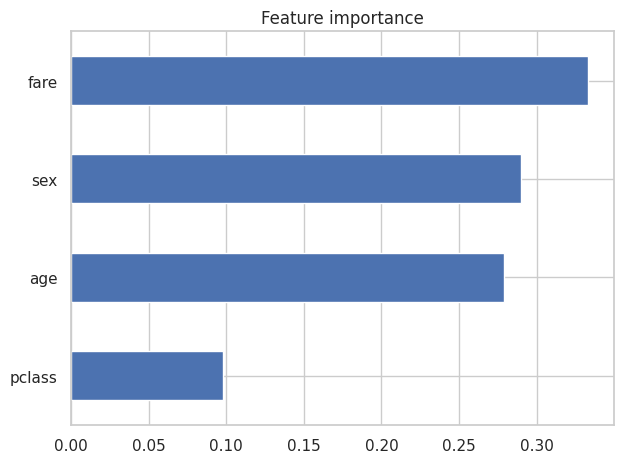

In [28]:
# -----------------------------------------------------------
# 🔹 5. END-TO-END MINI WORKFLOW
# -----------------------------------------------------------

# RAW  -> load the table (Pandas)
data = sns.load_dataset('titanic')

# CLEAN -> keep a few features, fill/drop missing, encode 'sex' (Pandas + NumPy)
data = data[['survived', 'pclass', 'sex', 'age', 'fare']].copy()
data['age'] = data['age'].fillna(data['age'].median())
data['sex'] = np.where(data['sex'] == 'male', 0, 1)   # encode to numbers
data = data.dropna()

# SPLIT -> features X and target y as NumPy arrays (NumPy)
X = data.drop(columns='survived').values
y = data['survived'].values
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

# MODEL -> fit + predict + score (scikit-learn)
model = RandomForestClassifier(random_state=42).fit(X_tr, y_tr)
acc = accuracy_score(y_te, model.predict(X_te))

# OUTPUT -> the result, plus a quick feature-importance chart (Matplotlib)
print('End-to-end Titanic survival accuracy:', round(acc, 3))

importances = pd.Series(model.feature_importances_,
                        index=data.drop(columns='survived').columns)
importances.sort_values().plot.barh(title='Feature importance')
plt.tight_layout(); plt.show()